# Cámara Oscura + Ecualización HSV

**Flujo:**
1. Capturar imagen con la cámara
2. Convertir a HSV
3. Separar canales H, S y V
4. Ecualizar únicamente el canal V
5. Recomponer y mostrar la imagen resultante

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Captura de imagen con la cámara

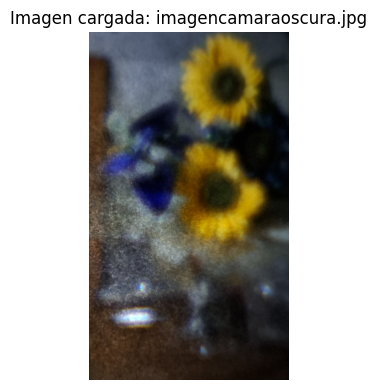

✓ Imagen cargada exitosamente
  Dimensiones: (2652, 1521, 3)


In [7]:
import os

# Ruta relativa a la carpeta de imágenes (desde el notebook actual)
# El notebook está en: 006_fotografia_digital/codigo/
# Las imágenes están en: 006_fotografia_digital/imagenes/originales/
carpeta_imagenes = os.path.join("..", "imagenes", "originales")

# Nombre de la imagen a cargar (cámbialo según tu archivo)
nombre_imagen = "imagencamaraoscura.jpg"
ruta_imagen = os.path.join(carpeta_imagenes, nombre_imagen)

# Crear ruta absoluta para mejor diagnóstico si hay error
ruta_absoluta = os.path.abspath(ruta_imagen)

frame_bgr = cv2.imread(ruta_imagen)

if frame_bgr is None:
    print(f"❌ Error: No se pudo cargar la imagen")
    print(f"   Ruta relativa: {ruta_imagen}")
    print(f"   Ruta absoluta: {ruta_absoluta}")
    print(f"\n   Archivos disponibles en {carpeta_imagenes}:")
    if os.path.exists(carpeta_imagenes):
        for archivo in os.listdir(carpeta_imagenes):
            print(f"   - {archivo}")
    raise RuntimeError(f"No se pudo cargar la imagen: {ruta_imagen}")

# Mostrar imagen cargada (BGR → RGB para matplotlib)
frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 4))
plt.imshow(frame_rgb)
plt.title(f"Imagen cargada: {nombre_imagen}")
plt.axis("off")
plt.tight_layout()
plt.show()

print(f"✓ Imagen cargada exitosamente")
print(f"  Dimensiones: {frame_bgr.shape}")

## 2. Conversión a HSV, separación de canales, ecualización de V y recomposición

In [8]:
# --- Paso 1: convertir BGR → HSV ---
imagen_hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)

# --- Paso 2: separar canales H, S, V ---
canal_h, canal_s, canal_v = cv2.split(imagen_hsv)

# --- Paso 3: ecualizar SOLO el canal V ---
canal_v_ecualizado = cv2.equalizeHist(canal_v)

# --- Paso 4: recomponer la imagen HSV con el V ecualizado ---
hsv_ecualizado = cv2.merge([canal_h, canal_s, canal_v_ecualizado])

# Convertir de vuelta a RGB para mostrar
resultado_rgb = cv2.cvtColor(hsv_ecualizado, cv2.COLOR_HSV2RGB)

## 3. Visualización: canales individuales y comparación original vs resultado

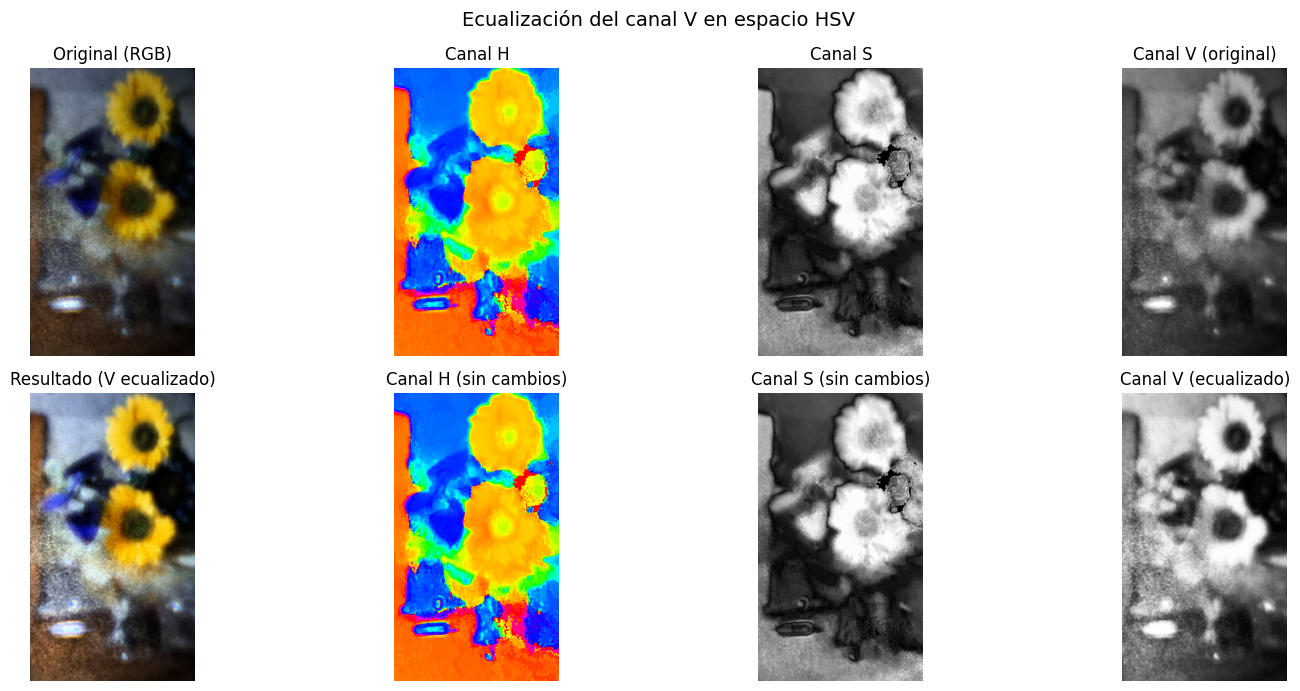

In [9]:
fig, ejes = plt.subplots(2, 4, figsize=(16, 7))

# Fila superior: canales originales
ejes[0, 0].imshow(frame_rgb)
ejes[0, 0].set_title("Original (RGB)")

ejes[0, 1].imshow(canal_h, cmap="hsv")
ejes[0, 1].set_title("Canal H")

ejes[0, 2].imshow(canal_s, cmap="gray")
ejes[0, 2].set_title("Canal S")

ejes[0, 3].imshow(canal_v, cmap="gray")
ejes[0, 3].set_title("Canal V (original)")

# Fila inferior: resultado ecualizado
ejes[1, 0].imshow(resultado_rgb)
ejes[1, 0].set_title("Resultado (V ecualizado)")

ejes[1, 1].imshow(canal_h, cmap="hsv")
ejes[1, 1].set_title("Canal H (sin cambios)")

ejes[1, 2].imshow(canal_s, cmap="gray")
ejes[1, 2].set_title("Canal S (sin cambios)")

ejes[1, 3].imshow(canal_v_ecualizado, cmap="gray")
ejes[1, 3].set_title("Canal V (ecualizado)")

for fila in ejes:
    for ax in fila:
        ax.axis("off")

plt.suptitle("Ecualización del canal V en espacio HSV", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Histogramas: antes y después de la ecualización

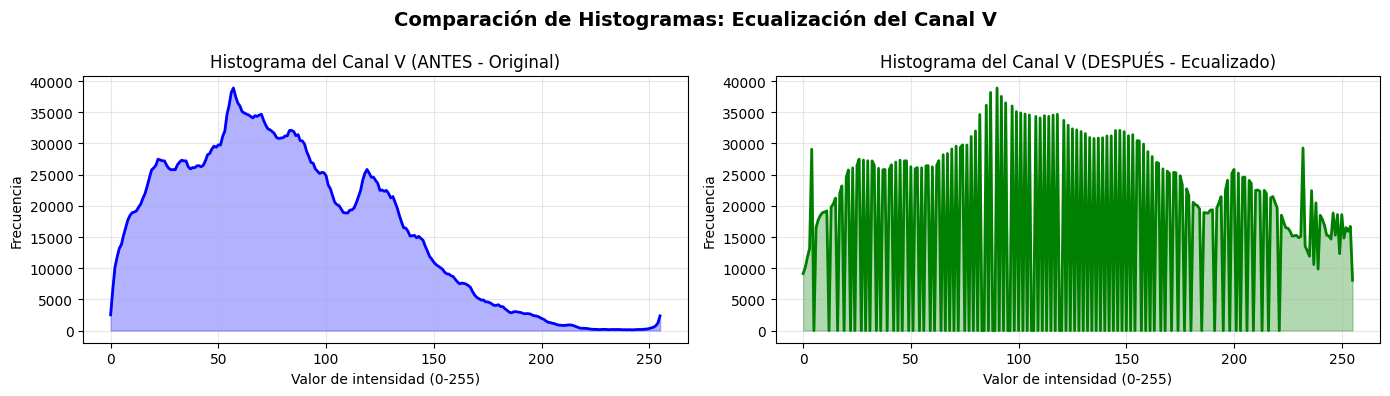

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Histograma ANTES (canal V original)
hist_v_original = cv2.calcHist([canal_v], [0], None, [256], [0, 256])
ax1.plot(hist_v_original, color='blue', linewidth=2)
ax1.set_title("Histograma del Canal V (ANTES - Original)", fontsize=12)
ax1.set_xlabel("Valor de intensidad (0-255)")
ax1.set_ylabel("Frecuencia")
ax1.grid(alpha=0.3)
ax1.fill_between(range(256), hist_v_original.flatten(), alpha=0.3, color='blue')

# Histograma DESPUÉS (canal V ecualizado)
hist_v_ecualizado = cv2.calcHist([canal_v_ecualizado], [0], None, [256], [0, 256])
ax2.plot(hist_v_ecualizado, color='green', linewidth=2)
ax2.set_title("Histograma del Canal V (DESPUÉS - Ecualizado)", fontsize=12)
ax2.set_xlabel("Valor de intensidad (0-255)")
ax2.set_ylabel("Frecuencia")
ax2.grid(alpha=0.3)
ax2.fill_between(range(256), hist_v_ecualizado.flatten(), alpha=0.3, color='green')

plt.suptitle("Comparación de Histogramas: Ecualización del Canal V", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Guardar imagen procesada

In [11]:
# Carpeta de salida para imágenes procesadas
carpeta_procesadas = os.path.join("..", "imagenes", "procesadas")

# Crear la carpeta si no existe
os.makedirs(carpeta_procesadas, exist_ok=True)

# Generar nombre del archivo de salida (basado en el nombre de entrada)
nombre_sin_extension = os.path.splitext(nombre_imagen)[0]
nombre_salida = f"{nombre_sin_extension}_ecualizado_V.jpg"
ruta_salida = os.path.join(carpeta_procesadas, nombre_salida)
ruta_salida_absoluta = os.path.abspath(ruta_salida)

# Convertir RGB → BGR para guardar con OpenCV (que usa BGR por defecto)
resultado_bgr = cv2.cvtColor(resultado_rgb, cv2.COLOR_RGB2BGR)

# Guardar la imagen
exito = cv2.imwrite(ruta_salida, resultado_bgr)

if exito:
    print(f"✅ Imagen guardada exitosamente")
    print(f"   Nombre: {nombre_salida}")
    print(f"   Ruta relativa: {ruta_salida}")
    print(f"   Ruta absoluta: {ruta_salida_absoluta}")
else:
    print(f"❌ Error al guardar la imagen")

✅ Imagen guardada exitosamente
   Nombre: imagencamaraoscura_ecualizado_V.jpg
   Ruta relativa: ..\imagenes\procesadas\imagencamaraoscura_ecualizado_V.jpg
   Ruta absoluta: c:\Users\cmpat\OneDrive\Escritorio\Repositorio\Patricio-Velasquez-Christian-PDI-1c-2026\006_fotografia_digital\imagenes\procesadas\imagencamaraoscura_ecualizado_V.jpg


## 6. Explicación de los cambios

### ¿Qué hicimos?

1. **Conversión a HSV**: La imagen RGB se convirtió a HSV para trabajar con los canales de color de forma independiente.

2. **Separación de canales**: Se separaron los tres canales:
   - **H (Hue)**: Define el color (0-180 en OpenCV)
   - **S (Saturation)**: Define la saturación del color (0-255)
   - **V (Value)**: Define el brillo/intensidad (0-255)

3. **Ecualización del canal V**: Se aplicó ecualización de histograma **solo** al canal V:
   - La ecualización expande la distribución de intensidades
   - Mejora el contraste y la visibilidad de detalles
   - Los píxeles oscuros se hacen más brillantes y los claros más claros

4. **Recomposición**: Se fusionaron los canales H y S sin cambios con el V ecualizado, creando una nueva imagen HSV.

5. **Conversión de vuelta**: Se convirtió HSV → RGB para visualizar el resultado.

6. **Guardado**: La imagen procesada se guarda automáticamente en `imagenes/procesadas/` con el sufijo `_ecualizado_V.jpg`.

---

### ¿Qué mejoró visualmente?

- **Mayor contraste**: La ecualización redistribuye los píxeles a lo largo de todo el rango de intensidad (0-255), creando diferencias más marcadas entre zonas claras y oscuras.
- **Mejor detalle**: Áreas oscuras o poco visibles ahora se ven con mayor nitidez y definición.
- **Preservación de color**: Como solo se modifica V (brillo), **los colores permanecen intactos** — no hay cambios de tonalidad en la imagen.
- **Resultado más "legible"**: La imagen procesada es más fácil de interpretar visualmente, especialmente en escenas con iluminación desigual.

### ¿Qué información se perdió?

- **Información de luminancia original**: La ecualización reexpande el histograma, por lo que se pierde la información exacta de cómo estaban distribuidas las intensidades originalmente.
- **Detalles en áreas saturadas**: Si la imagen original tenía píxeles en valores extremos (muy oscuros o muy claros), algunos detalles en esas regiones pueden no recuperarse totalmente.
- **Naturalidad**: La imagen puede verse "artificial" o sobreprocessada, especialmente si originalmente tenía una iluminación intencional (ej: sombras artísticas).
- **Rango dinámico original**: Se pierde la relación de brillo original entre objetos, aunque se gana en visibilidad general.

### ¿Qué limitaciones tiene la cámara oscura?

La **cámara oscura** (física) tiene limitaciones importantes:

- **Inversión de imagen**: La imagen se captura invertida (180°), requiriendo corrección óptica o digital.
- **Tamaño limitado**: El tamaño de la imagen final depende de la distancia focal y el tamaño de la apertura.
- **Exposición lenta**: Requiere mucho tiempo de exposición (no hay sensor rápido), resultando en imágenes borrosas si hay movimiento.
- **Sin control automático**: No hay enfoque automático, balance de blancos, ni control de exposición dinámico.
- **Resolución limitada**: La calidad depende del material de proyección, no hay captura digital de alta resolución.
- **Condiciones de luz**: Requiere ambientes oscuros y sujetos muy iluminados para funcionar correctamente.


### ¿Por qué se ecualiza el canal V y no RGB directamente?

**Razones técnicas y visuales:**

1. **Separación de variables**: En HSV, el brillo (V) está **desacoplado** del color. En RGB, los tres canales están entrelazados — cambiar uno afecta la percepción de color.

2. **Preservación de color natural**: Si ecualizamos cada canal RGB por separado:
   - Cada canal (R, G, B) se expande independientemente
   - Se distorsionan las proporciones de color originales
   - El resultado puede tener colores no naturales (color shift)
   
3. **Con ecualización en V**:
   - Solo modificamos el brillo, manteniendo exactamente los mismos colores
   - La relación R:G:B se preserva en cada píxel
   - Resultado mucho más natural y reconocible

4. **Ejemplo práctico**:
   - Imagen RGB original: píxel rojo oscuro = (80, 20, 20)
   - Ecualización RGB directa → podría resultar: (200, 50, 50) → rojo más brillante pero saturado
   - Ecualización en V → HSV: (0°, 75%, 31%) → (0°, 75%, 75%) → Rojo igual de saturado, solo más brillante ✓

5. **Histograma equilibrado**: La ecualización en V se enfoca en distribuir uniformemente el brillo, sin "tirar" de los canales de color individuales en direcciones diferentes.

### Beneficios del enfoque HSV:
- ✅ Preserva los colores originales (H y S no cambian)
- ✅ Solo se mejora el contraste/brillo (V)
- ✅ La ecualización del histograma distribuye mejor las intensidades de luz
- ✅ Resultado: imagen más clara y con mejor definición de detalles
- ✅ Imagen procesada guardada automáticamente en la carpeta de salida
- ✅ Colores naturales sin artefactos ni color shift